# <center>Exercise 4_Linear Regression<center> 

 <font size ="2">**Name: Li Xingjian**  
 **Group: FSP6**  
 **Matric: U2022889J**  

***

## Problem 1

In [2]:
# Basic Libraries
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt 
sb.set() 

In [3]:
# import the dataset
houseData = pd.read_csv('train.csv')
houseData.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


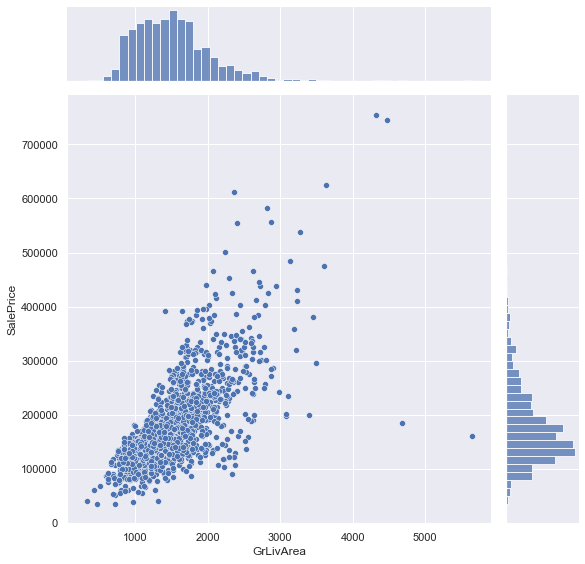

In [4]:
# Plot SalePrice against GrLivArea using any appropriate bivariate plot to note the strong linear relationship
SalePrice = pd.DataFrame(houseData['SalePrice'])
GrLivArea = pd.DataFrame(houseData['GrLivArea'])

jointDF = pd.concat([SalePrice, GrLivArea], axis = 1).reindex(SalePrice.index)
sb.jointplot(data = jointDF, x = "GrLivArea", y = "SalePrice", height = 8)

<AxesSubplot:>

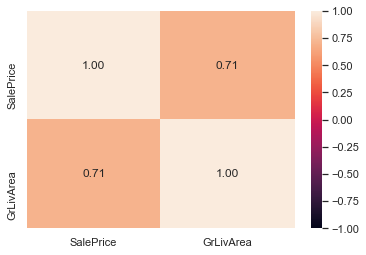

In [5]:
# Print the correlation coefficient between these two variables to get a numerical evidence of the relationship 
sb.heatmap(jointDF.corr(), vmin = -1, vmax = 1, annot = True, fmt = ".2f")

As illustrated in the jointplot and heatmap, variables "SalePrice" and "GrLivArea" have strong linear relationship.

In [74]:
# Import Linear Regression model from Scikit-Learn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
lg = LinearRegression()

Intercept of Regression 	: b =  [23263.72677152]
Coefficients of Regression 	: a =  [[103.1162603]]



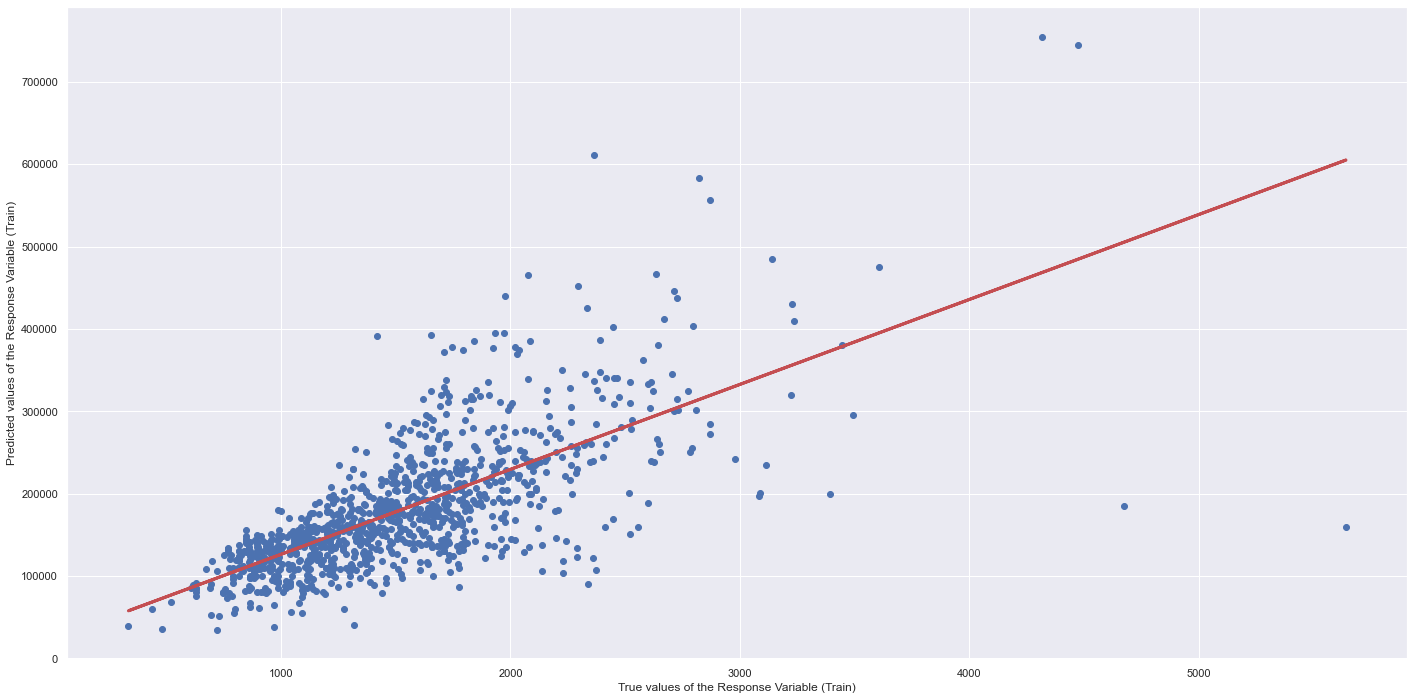

In [75]:
# Partition the dataset houseData into two “random” portions : Train Data (1100 rows) and Test Data (360 rows)
X_train, X_test, y_train, y_test = train_test_split(GrLivArea, SalePrice, test_size = 0.2465753425)

# Training : Fit a Linear Regression model on the Train Dataset to predict or estimate SalePrice using GrLivArea
lg.fit(X_train, y_train)

# Print the coefficients of the Linear Regression model you just fit
print('Intercept of Regression \t: b = ', lg.intercept_)
print('Coefficients of Regression \t: a = ', lg.coef_)
print()

# Plot the regression line on a scatterplot.
y_train_pred = lg.predict(X_train)
y_test_pred = lg.predict(X_test)

f, ax = plt.subplots(1, 1,figsize = (24, 12))
regline_x = X_train
regline_y = lg.intercept_ + lg.coef_ * X_train
plt.scatter(X_train, y_train)
plt.plot(regline_x, regline_y, 'r-', linewidth = 3)
ax.set_xlabel("True values of the Response Variable (Train)")
ax.set_ylabel("Predicted values of the Response Variable (Train)")
plt.show()

In [76]:
# Print Explained Variance (R^2) and Mean Squared Error (MSE) on Train Data to check Goodness of Fit of model
print("Explained Variance (R^2) \t:", lg.score(X_train, y_train))

def mean_sq_err(actual, predicted):
    return np.mean(np.square(np.array(actual) - np.array(predicted)))
print("Mean Squared Error (MSE) \t:", mean_sq_err(y_train, y_train_pred))

Explained Variance (R^2) 	: 0.4936580674765181
Mean Squared Error (MSE) 	: 3154929803.947025


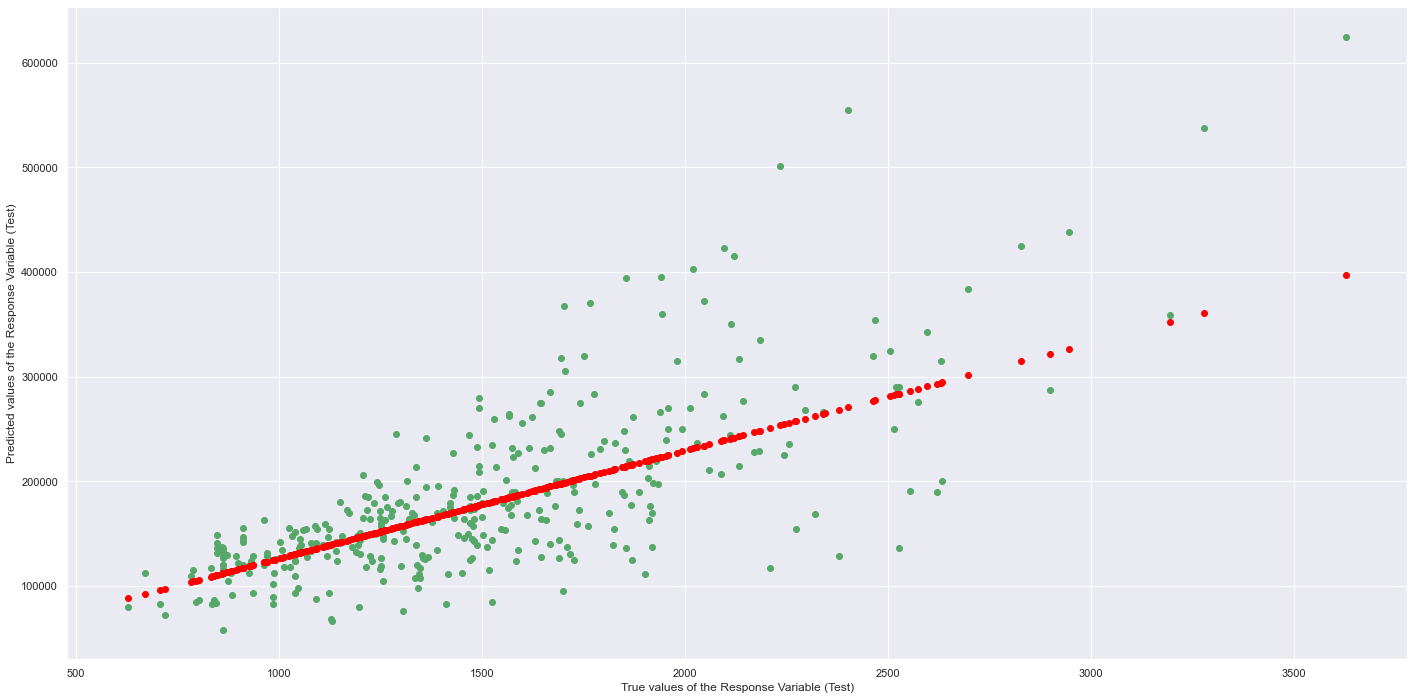

In [77]:
# Predict SalePrice in case of Test Data 
f, ax = plt.subplots(1, 1,figsize = (24, 12))

plt.scatter(X_test, y_test,color = 'g')
plt.scatter(X_test, y_test_pred, color = "red")
ax.set_xlabel("True values of the Response Variable (Test)")
ax.set_ylabel("Predicted values of the Response Variable (Test)")
plt.show()

In [79]:
# Print the Mean Squared Error (MSE) on Test Data to check Goodness of Fit of model
print("Explained Variance (R^2) \t:", lg.score(X_test, y_test))
print("Mean Squared Error (MSE) \t:", mean_squared_error(y_test, y_test_pred))
print()

Explained Variance (R^2) 	: 0.5218340555919299
Mean Squared Error (MSE) 	: 3119694136.7117844



## Problem 2

***Similarly, three other linear regressions will be conducted in generalization.***

In [88]:
Case = ['LotArea', 'TotalBsmtSF', 'GarageArea']

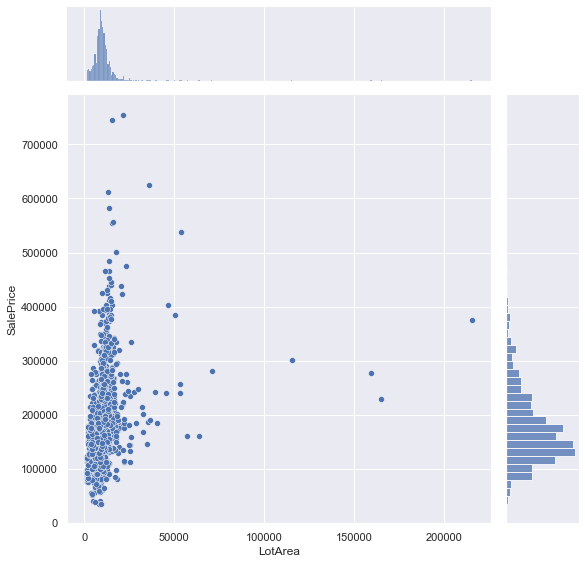

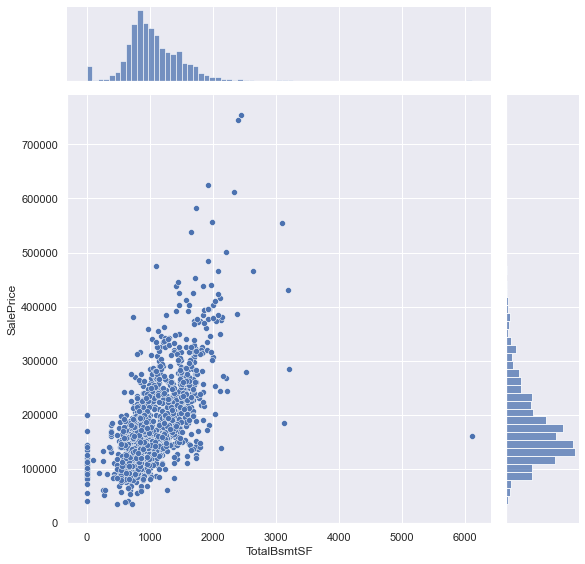

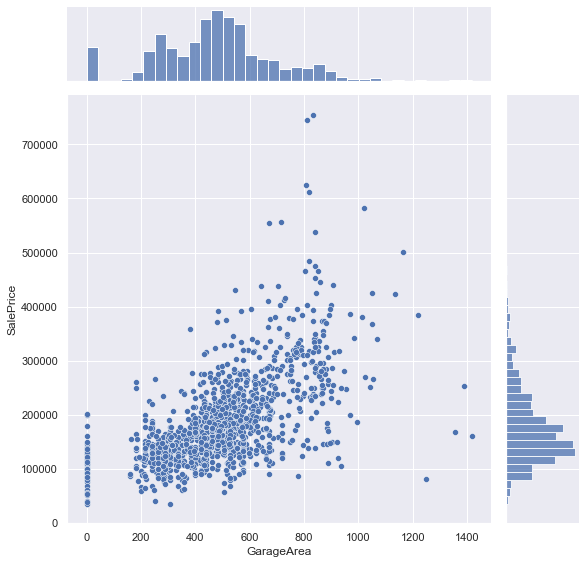

In [95]:
SalePrice = pd.DataFrame(houseData['SalePrice'])

for i,item in enumerate(Case):
    
    d = houseData[item]
    jointDF = pd.concat([SalePrice, d], axis = 1).reindex(SalePrice.index)
    sb.jointplot(data = jointDF, x = item, y = "SalePrice", height = 8)

bi-relation between SalePrice and  LotArea
Intercept 	: b =  [159991.93906741]
Coefficients 	: a =  [[1.81609942]]

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.06577646065471077
Mean Squared Error (MSE) 	: 5657588507.9984045

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: 0.06927083699464376
Mean Squared Error (MSE) 	: 6543724247.898477


bi-relation between SalePrice and  TotalBsmtSF
Intercept 	: b =  [69348.26917693]
Coefficients 	: a =  [[105.27981928]]

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.3515797739949328
Mean Squared Error (MSE) 	: 4117206004.439237

Goodness of Fit of Model 	Test Dataset
Explained Variance (R^2) 	: 0.4488900848313334
Mean Squared Error (MSE) 	: 3404380089.301288


bi-relation between SalePrice and  GarageArea
Intercept 	: b =  [67386.81556842]
Coefficients 	: a =  [[237.98360752]]

Goodness of Fit of Model 	Train Dataset
Explained Variance (R^2) 	: 0.3951021517534974
Mean Squared Erro

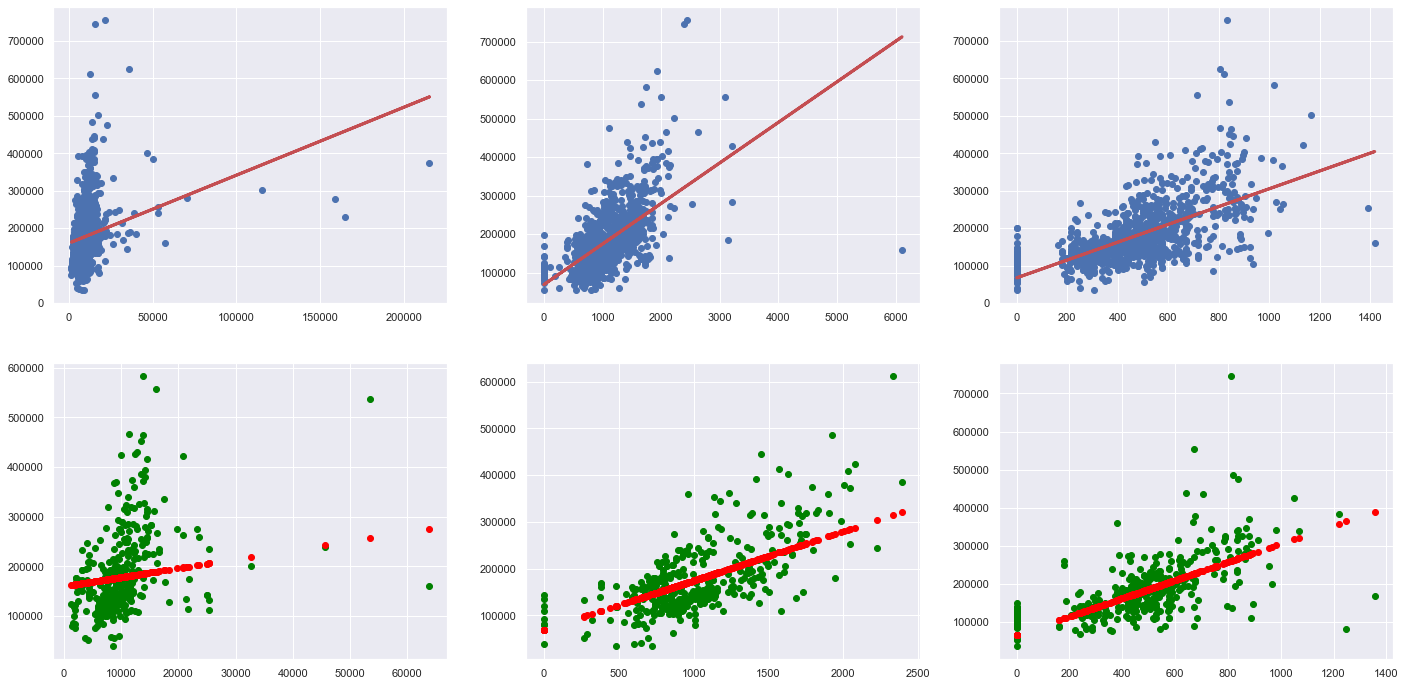

<Figure size 1152x576 with 0 Axes>

<Figure size 1152x576 with 0 Axes>

<Figure size 1152x576 with 0 Axes>

In [90]:
y_sale = pd.DataFrame(houseData['SalePrice'])

f,axes= plt.subplots(2, 3, figsize=(24, 12))

for i,item in enumerate(Case):
    print("bi-relation between SalePrice and ", item)
    
    x_item= pd.DataFrame(houseData[item])
    
    x_train, x_test, y_train, y_test = train_test_split(x_item,y_sale,train_size=0.75)
    
    linreg= LinearRegression()
    linreg.fit(x_train,y_train)
    
    print('Intercept \t: b = ', linreg.intercept_)
    print('Coefficients \t: a = ', linreg.coef_)
    print()
    
    y_train_pred = linreg.predict(x_train)
    y_test_pred = linreg.predict(x_test)
    
    regline_x = x_train
    regline_y = linreg.intercept_ + linreg.coef_ * x_train
    
    print("Goodness of Fit of Model \tTrain Dataset")
    print("Explained Variance (R^2) \t:", linreg.score(x_train, y_train))
    print("Mean Squared Error (MSE) \t:", mean_squared_error(y_train, y_train_pred))
    print()
    
    print("Goodness of Fit of Model \tTest Dataset")
    print("Explained Variance (R^2) \t:", linreg.score(x_test, y_test))
    print("Mean Squared Error (MSE) \t:", mean_squared_error(y_test, y_test_pred))
    print()
    print()
    
    f = plt.figure(figsize=(16,8))
    axes[0,i].scatter(x_train, y_train)
    axes[0,i].plot(regline_x, regline_y, 'r', linewidth=3)
    axes[1,i].scatter(x_test, y_test,color='green')
    axes[1,i].scatter(x_test, y_test_pred, color = "red")
    


## Problem 3

R^2: GrLivArea > TotalBsmtSF/GarageArea > LotArea  

MSE: LotArea > TotalBsmtSF/GarageArea/GrLivArea 

As larger R^2 is and the smaller the MSE is, the better the model is.
Thus, GrLivArea-SalePrice model is relativelt better to predict. 